  Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.0-cp311-cp311-macosx_10_9_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl (270 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.0-cp311-cp311-macosx_10_9_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-macosx_11_0_arm64.whl (63 kB)
Using cached pillow-12.1.1-cp311-cp311-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-p

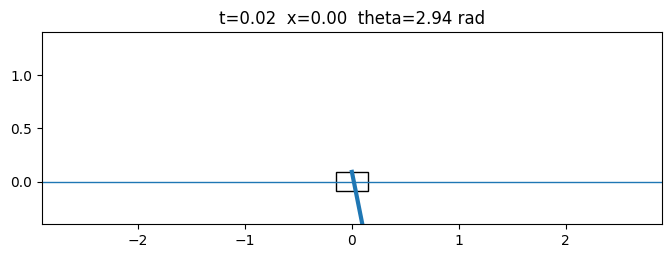

In [3]:
!pip install numpy
!pip install matplotlib

import math
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np


@dataclass
class CartPoleConfig:
    # physical parameters
    m_cart: float = 1.0
    m_pole: float = 0.1
    pole_half_length: float = 0.5   # half the pole length
    gravity: float = 9.81

    # control / integration
    dt: float = 0.02
    force_limit: float = 10.0

    # termination
    x_threshold: float = 2.4
    theta_threshold_radians: float = 12.0 * math.pi / 180.0

    # reward shaping
    alive_reward: float = 1.0


class CartPoleSim:
    """
    A minimal MuJoCo-like cartpole clone:
      state = [x, x_dot, theta, theta_dot]
    where theta = 0 means pole is upright.

    Positive action pushes the cart to the right.
    """

    def __init__(self, config: Optional[CartPoleConfig] = None, seed: Optional[int] = None):
        self.cfg = config or CartPoleConfig()
        self.rng = np.random.default_rng(seed)
        self.state = np.zeros(4, dtype=np.float64)
        self.time = 0.0

    def reset(self, noise_scale: float = 0.01) -> np.ndarray:
        self.state = self.rng.uniform(-noise_scale, noise_scale, size=4).astype(np.float64)
        self.time = 0.0
        return self.state.copy()

    def set_state(self, x: float, x_dot: float, theta: float, theta_dot: float) -> None:
        self.state[:] = [x, x_dot, theta, theta_dot]

    def get_state(self) -> np.ndarray:
        return self.state.copy()

    def _clip_force(self, u: float) -> float:
        return float(np.clip(u, -self.cfg.force_limit, self.cfg.force_limit))

    def dynamics(self, state: np.ndarray, action: float) -> np.ndarray:
        """
        Continuous-time dynamics:
            d/dt [x, x_dot, theta, theta_dot]
        based on the standard cartpole equations.
        """
        x, x_dot, theta, theta_dot = state
        force = self._clip_force(action)

        m_c = self.cfg.m_cart
        m_p = self.cfg.m_pole
        total_mass = m_c + m_p
        l = self.cfg.pole_half_length
        g = self.cfg.gravity

        sin_theta = math.sin(theta)
        cos_theta = math.cos(theta)

        # Common intermediate term
        temp = (force + m_p * l * theta_dot**2 * sin_theta) / total_mass

        # Pole angular acceleration
        theta_ddot = (g * sin_theta - cos_theta * temp) / (
            l * (4.0 / 3.0 - (m_p * cos_theta**2) / total_mass)
        )

        # Cart acceleration
        x_ddot = temp - (m_p * l * theta_ddot * cos_theta) / total_mass

        return np.array([x_dot, x_ddot, theta_dot, theta_ddot], dtype=np.float64)

    def _rk4_step(self, state: np.ndarray, action: float, dt: float) -> np.ndarray:
        k1 = self.dynamics(state, action)
        k2 = self.dynamics(state + 0.5 * dt * k1, action)
        k3 = self.dynamics(state + 0.5 * dt * k2, action)
        k4 = self.dynamics(state + dt * k3, action)
        return state + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    def is_terminated(self, state: Optional[np.ndarray] = None) -> bool:
        s = self.state if state is None else state
        x, _, theta, _ = s
        return (
            abs(x) > self.cfg.x_threshold
            or abs(theta) > self.cfg.theta_threshold_radians
        )

    def reward(self, state: Optional[np.ndarray] = None) -> float:
        done = self.is_terminated(state)
        return 0.0 if done else self.cfg.alive_reward

    def step(self, action: float) -> Tuple[np.ndarray, float, bool, dict]:
        self.state = self._rk4_step(self.state, action, self.cfg.dt)
        self.time += self.cfg.dt
        done = self.is_terminated(self.state)
        reward = self.reward(self.state)
        info = {"time": self.time}
        return self.state.copy(), reward, done, info


class CartPoleViewer:
    def __init__(self, sim: CartPoleSim):
        self.sim = sim

    def render(self) -> None:
        import matplotlib.pyplot as plt

        x, _, theta, _ = self.sim.get_state()
        l = self.sim.cfg.pole_half_length
        track_half = self.sim.cfg.x_threshold + 0.5

        cart_y = 0.0
        cart_w = 0.3
        cart_h = 0.18

        pole_x0 = x
        pole_y0 = cart_y + cart_h / 2.0
        pole_x1 = pole_x0 + 2.0 * l * math.sin(theta)
        pole_y1 = pole_y0 + 2.0 * l * math.cos(theta)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.set_xlim(-track_half, track_half)
        ax.set_ylim(-0.4, 1.4)
        ax.axhline(0.0, linewidth=1)

        # cart
        rect = plt.Rectangle((x - cart_w / 2, cart_y - cart_h / 2), cart_w, cart_h, fill=False)
        ax.add_patch(rect)

        # pole
        ax.plot([pole_x0, pole_x1], [pole_y0, pole_y1], linewidth=3)
        ax.plot(pole_x1, pole_y1, marker="o")

        ax.set_title(
            f"t={self.sim.time:.2f}  x={x:.2f}  theta={theta:.2f} rad"
        )
        ax.set_aspect("equal", adjustable="box")
        plt.show()


def pd_swingup_controller(state: np.ndarray) -> float:
    """
    Very rough hand-written controller.
    Works somewhat near upright, not a robust optimal controller.
    """
    x, x_dot, theta, theta_dot = state

    # wrap theta to [-pi, pi]
    theta = ((theta + math.pi) % (2 * math.pi)) - math.pi

    # simple stabilizer around theta = 0
    k_theta = -80.0
    k_theta_dot = -12.0
    k_x = -1.0
    k_x_dot = -2.0

    u = (
        k_theta * theta
        + k_theta_dot * theta_dot
        + k_x * x
        + k_x_dot * x_dot
    )
    return float(u)


if __name__ == "__main__":
    sim = CartPoleSim(seed=0)
    s = sim.reset()

    # Uncomment this to start near upright:
    # sim.set_state(x=0.0, x_dot=0.0, theta=0.05, theta_dot=0.0)

    # Start near downward for fun:
    sim.set_state(x=0.0, x_dot=0.0, theta=math.pi - 0.2, theta_dot=0.0)

    total_reward = 0.0
    traj = []

    for t in range(500):
        s = sim.get_state()

        # crude demo controller
        # near upright -> PD stabilize, otherwise push by pole direction
        angle_wrapped = ((s[2] + math.pi) % (2 * math.pi)) - math.pi
        if abs(angle_wrapped) < 0.5:
            u = pd_swingup_controller(s)
        else:
            u = 8.0 * np.sign(math.sin(angle_wrapped)) - 1.0 * s[1]

        ns, r, done, info = sim.step(u)
        total_reward += r
        traj.append(ns)

        if done:
            print(f"Terminated at step {t}, state={ns}")
            break

    print("Final state:", sim.get_state())
    print("Total reward:", total_reward)

    # show final frame
    viewer = CartPoleViewer(sim)
    viewer.render()